
# Non Linear Regression


## Demo

- importing libraries and reading the file 
- painting some Non-Linear-Regression plots
- choosing, building, normalizing the model 
- showing the output 

<h2 id="importing_libraries">Importing required libraries</h2>


In [190]:
import numpy as np
import matplotlib.pyplot as plt

Despite the general effectiveness of linear regression in representing a dataset, it does not always work for all datasets. First, let us quickly revisit how linear regression works to model a dataset. Linear regression represents a linear relationship between a dependent variable y and independent variables x. It has a simple equation therefore of degree 1, for example y = $2x$ + 3.

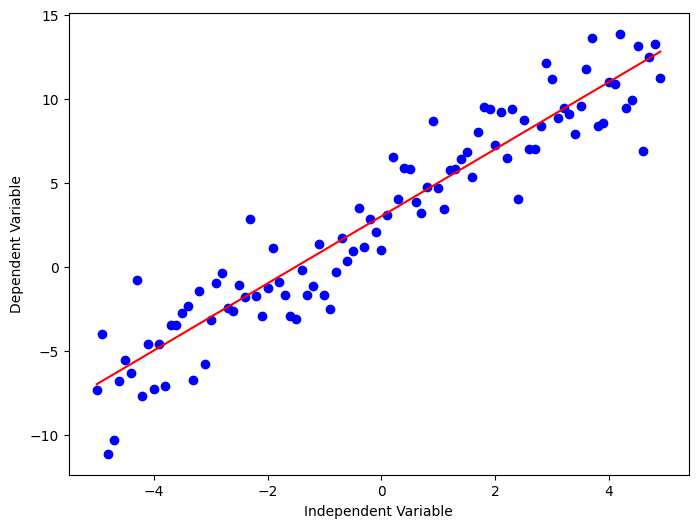

In [191]:
x = np.arange(-5.0, 5.0, 0.1)




y = 2*(x) + 3
y_noise = 2 * np.random.normal(size=x.size)
ydata = y + y_noise
plt.figure(figsize=(8,6))
plt.plot(x, ydata,  'bo')
plt.plot(x,y, 'r') 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

Non-linear regression is used to model relationships between variables where the relationship isn't a straight line. Instead of using simple linear equations, it involves more complex functions. For example, a polynomial equation like:

$y = a x^3 + b x^2 + c x + d$

represents a non-linear relationship between \$x\$ and \$y\$. Non-linear functions can also include elements like exponentials, logarithms, and fractions. For instance, a simple non-linear function could be:

$y = \log(x)$

It’s even possible to have more complicated expressions, like:

$y = \log(a x^3 + b x^2 + c x + d)$



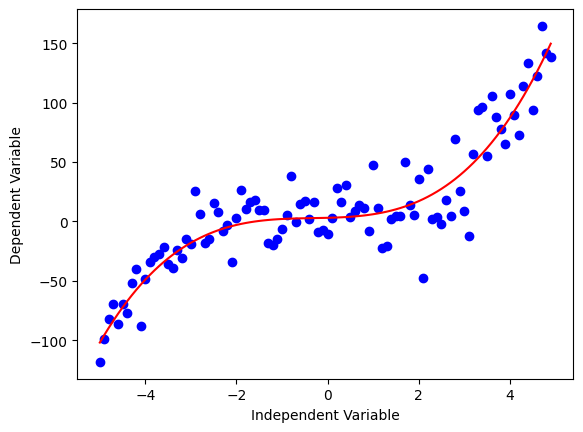

In [192]:
x = np.arange(-5.0, 5.0, 0.1)

y = 1*(x**3) + 1*(x**2) + 1*x + 3
# Cause we want to have a plot and it should have some noise 
y_noise = 20 * np.random.normal(size=x.size)
ydata = y + y_noise


plt.plot(x, ydata,  'bo')
plt.plot(x,y, 'r') 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

As you may see, this function has both an independent variable of $x^3$ and an independent variable of $x^2$. Also, this graphic of this function is not linear over the 2D plane. Therefore, this is a non-linear function.

#### Some Other:

### Quadratic


$$ Y = X^2 $$


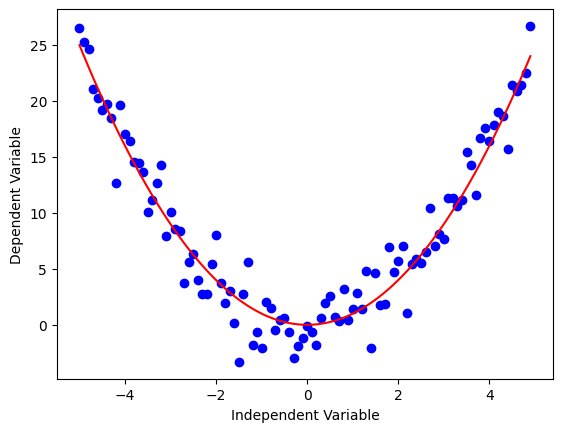

In [193]:
x = np.arange(-5.0, 5.0, 0.1)



y = np.power(x,2)
y_noise = 2 * np.random.normal(size=x.size)
ydata = y + y_noise
plt.plot(x, ydata,  'bo')
plt.plot(x,y, 'r') 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

### Exponential


An exponential function with base c is written as $$ Y = a + b c^X$$ with b ≠0, c > 0, c ≠1, and x can be any real number. The base c is constant and the exponent x is a variable.

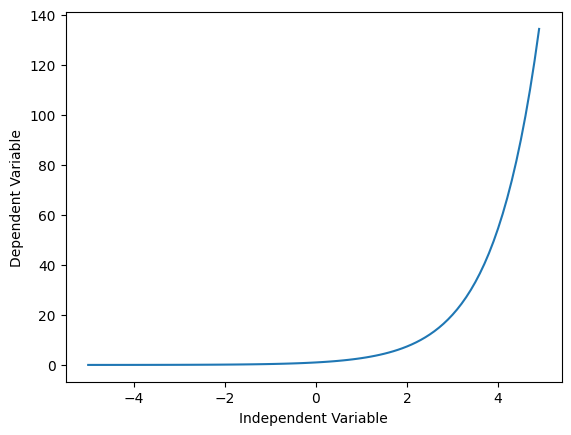

In [194]:
X = np.arange(-5.0, 5.0, 0.1)




Y= np.exp(X)

plt.plot(X,Y) 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

### Logarithmic

The response $y$ is the result of applying the logarithmic function to the input $x$, transforming it into the output $y$. A simple form of this is:

$y = \log(x)$

However, rather than using a simple $x$, we can use a more complex expression for $X$, which could be a polynomial representation of $x$. In general, this can be written as:

$y = \log(X)$

Here, $X$ represents a polynomial or more complex function of $x$, and the logarithmic map is applied to it to get the corresponding output $y$.



C:\Users\Arya\AppData\Local\Temp\ipykernel_11748\775561722.py:4: RuntimeWarning: invalid value encountered in log
  Y = np.log(X)


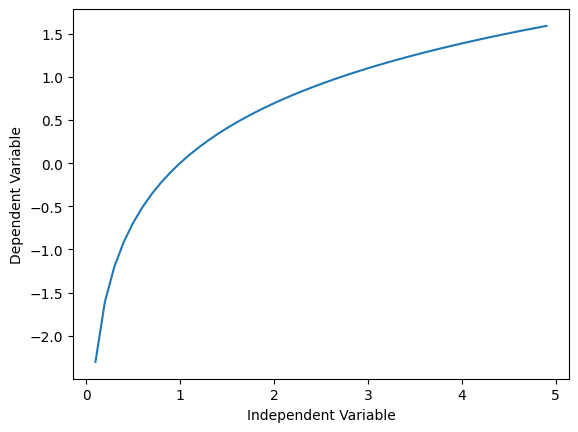

In [195]:
X = np.arange(-5.0, 5.0, 0.1)


Y = np.log(X)



plt.plot(X,Y) 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

### Sigmoidal/Logistic


$$ Y = a + \frac{b}{1+ c^{(X-d)}}$$


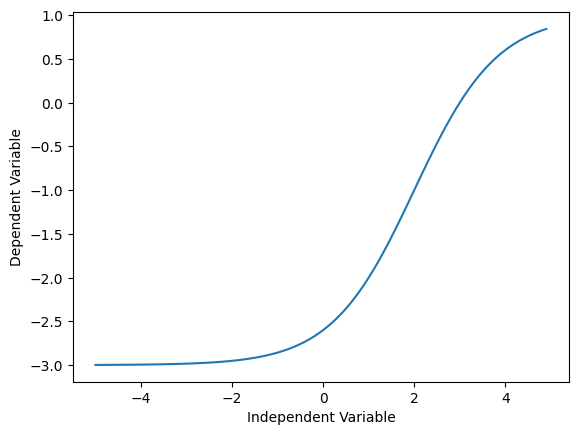

In [196]:
X = np.arange(-5.0, 5.0, 0.1)


Y = 1-4/(1+np.power(3, X-2))

plt.plot(X,Y) 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

<a id="ref2"></a>

# Non-Linear Regression example


As an example, we will attempt to fit a non-linear model to the data points for China's GDP between the years 1960 and 2014. We will download a data set that has two columns: the first is a year (between 1960 and 2014), and the second is China's corresponding annual gross domestic product in US dollars for that year.

In [197]:
import numpy as np
import pandas as pd

    
df = pd.read_csv("Regression/china_gdp.csv")
df.head(10)

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10
5,1965,6.970915e+10
6,1966,7.587943e+10
7,1967,7.205703e+10
8,1968,6.999350e+10
9,1969,7.871882e+10


### Plotting the Dataset and the data's

This is what the data points appear as. It resembles an logistic or exponential function type of curve. Growth begins slowly, then from 2005 onward growth is extremely rapid. Finally, it has decelerated slightly during the 2010s.

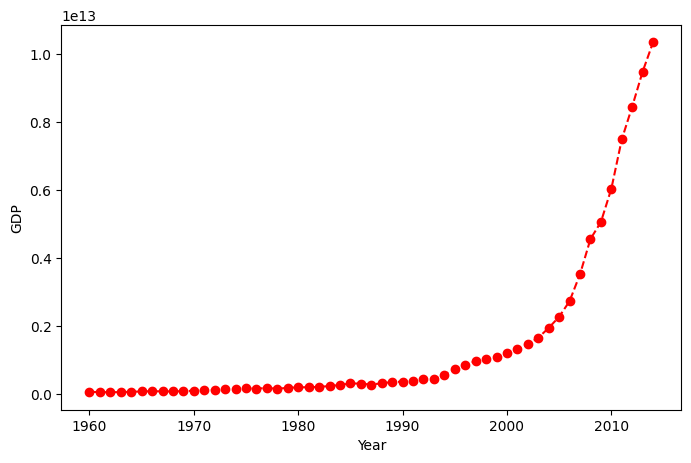

In [198]:
plt.figure(figsize=(8,5))
x_data, y_data = (df["Year"].values, df["Value"].values)
plt.plot(x_data, y_data, 'r--o')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

### Selecting a model

After a first glance at the plot, we conclude that the logistic function might be reasonable, since it has the property of starting from low growth, increasing growth in the middle then decreasing again in the end; as shown below:

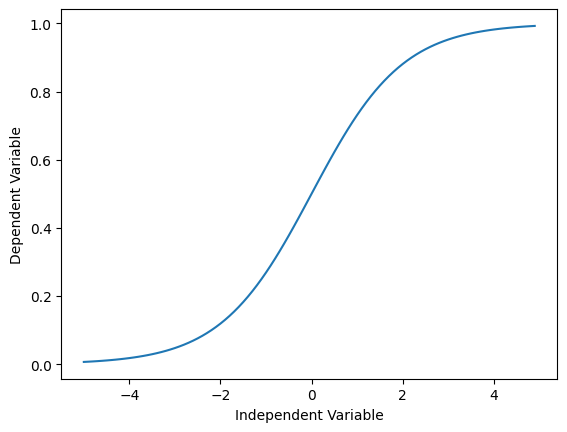

In [199]:
X = np.arange(-5.0, 5.0, 0.1)
Y = 1 / (1 + np.exp(-X))


plt.plot(X,Y) 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

The Formula is like this :



$$ \hat{Y} = \frac1{1+e^{\beta\_1(X-\beta\_2)}}$$



$\beta\_1$: Controls the curve's steepness,

$\beta\_2$: Slides the curve on the x-axis.


### Building The Model

so, Its time to train and building the model 

In [200]:
def sigmoid(x, Beta_1, Beta_2):
     y = 1 / (1 + np.exp(-Beta_1*(x-Beta_2)))
     return y

Calling the func :

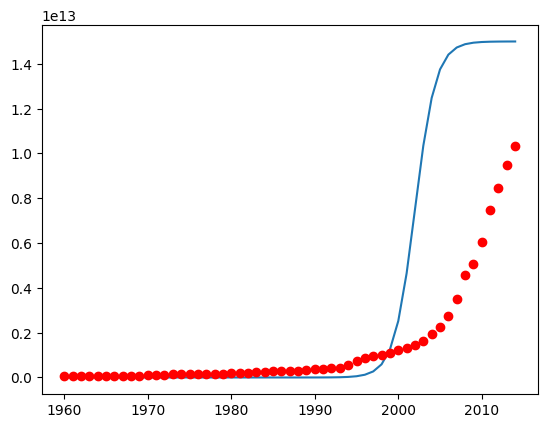

In [201]:
beta_1 = 0.8
beta_2 = 2002.0

#logistic function
Y_pred = sigmoid(x_data, beta_1 , beta_2)

#plot initial prediction against datapoints
plt.plot(x_data, Y_pred*15000000000000.)
plt.plot(x_data, y_data, 'ro')

## Normalization
We need to normalize the Beta1 and Beta2 data so that it has a value from 0 to 1. 
How do you do that?

by dividing by the max value in the array.

In [202]:
# Lets normalize our data
xdata =x_data/max(x_data)
ydata =y_data/max(y_data)

# to have a number bitween 0 and 1 
# so i have to do this :
# x / max(x)
# y = max(y)

## How we find the best parameters for our fit line?


We can use **curve\_fit**, which applies non-linear least squares to fit a sigmoid function to the data. It finds the optimal values for the parameters that minimize the sum of the squared residuals, i.e., the difference between $\text{sigmoid}(x_{\text{data}}, *\text{popt})$ and $y_{\text{data}}$.

The values in $\text{popt}$ are the optimized parameters.


In [203]:
from scipy.optimize import curve_fit
popt, pcov = curve_fit(sigmoid, xdata, ydata)



print(" beta_1 = %f, beta_2 = %f" % (popt[0], popt[1]))

 beta_1 = 690.451712, beta_2 = 0.997207


Now, We can plot it 

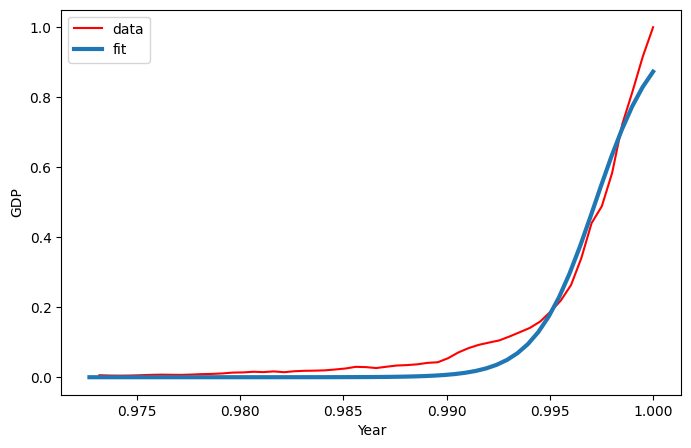

In [204]:
x = np.linspace(1960, 2015, 55)
x = x/max(x)
plt.figure(figsize=(8,5))
y = sigmoid(x, *popt)
plt.plot(xdata, ydata, 'r-', label='data')
plt.plot(x,y, linewidth=3.0, label='fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

## accuracy of the model


In [205]:
msk = np.random.rand(len(df)) < 0.8
train_x = xdata[msk]
test_x = xdata[~msk]
train_y = ydata[msk]
test_y = ydata[~msk]





popt, pcov = curve_fit(sigmoid, train_x, train_y)



y_hat = sigmoid(test_x, *popt)



print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_hat - test_y) ** 2))
from sklearn.metrics import r2_score
print("R2-score: %.2f" % r2_score(y_hat , test_y) )




Mean absolute error: 0.04
Residual sum of squares (MSE): 0.00
R2-score: 0.96
